# solveit-tex

A utility for creating LaTeX papers using SolveIT, to facilitate Human-Authored, Computer-Interrogated (HACI) writing workflows.

The idea is to be able to work in Solvit and see somewhat of what you're working on and be able to interrogate it via the AI incrementally and then have it generate a paper.

Full interoperability between Solve It and LaTeX isn't entirely something I'm going for, but I'm trying to make it so that things that render In one medium, render in the other to as high a degree as possible.

In [ ]:
#| export
import os, subprocess, json, re, sys
from pathlib import Path
from IPython.display import HTML, display

## Utilities called by other routines

In [ ]:
#| export
async def get_curr_dialog_path():
    from dialoghelper.solveitskill import curr_dialog, realpath
    name = (await curr_dialog())['name']
    return f'{await realpath("/")}/{name}.ipynb'

In [ ]:
curr_dialog_path = await get_curr_dialog_path()
print(curr_dialog_path)
print(type(curr_dialog_path))

/app/data/solveit-tex/solveit-tex.ipynb


<class 'str'>


In [ ]:
#| export
def get_private_url(path: str):
    "Get the private URL for a file on the solveit cloud instance"
    server = os.getenv('PRIVATE_DOMAIN')
    if not server: raise ValueError("PRIVATE_DOMAIN not set")
    path = os.path.abspath(path)
    return f"https://{server}.solve.it.com{path.replace('/app/data', '/static')}"

In [ ]:
get_private_url(curr_dialog_path) 

'https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/solveit-tex.ipynb'

### Figures

In [ ]:
def parse_figure(line: str):
    r"""Parse markdown figure syntax with multiple images on one line: ![alt1](img1.png) ![alt2](img2.png)\{width=45% #fig:label}
     Images on one line get grouped into a single figure, with the final caption and label being the one used for the group"""
    import re
    
    # Look for escaped attributes at the end: \{...}
    attrs = ''
    attr_match = re.search(r'\\\{([^}]*)\}\s*$', line)
    if attr_match:
        attrs = attr_match.group(1)
        line = line[:attr_match.start()]  # Remove the attributes part
    
    # Find all image patterns on the line
    pattern = r'!\[([^\]]*)\]\(([^)]+)\)'
    matches = re.findall(pattern, line.strip())
    
    if not matches: return None
    
    images = []
    caption = ""
    
    for i, (alt, path) in enumerate(matches):
        img = {'path': path.strip()}
        images.append(img)
        
        # Last image sets the caption and label
        if i == len(matches) - 1:
            caption = alt
    
    # Extract width and label from attributes
    width_m = re.search(r'width=([^\s#]+)', attrs)
    label_m = re.search(r'#fig:([^\s}]+)', attrs)
    width = width_m.group(1) if width_m else None
    label = label_m.group(1) if label_m else None
    
    # Apply width to all images if specified
    if width:
        for img in images:
            img['width'] = width
    
    # If caption is just a filename, treat as no caption
    if caption:
        path_basenames = [Path(p['path']).name for p in images]
        if caption in path_basenames or caption in [p['path'] for p in images]:
            caption = ""
    
    return {'caption': caption, 'images': images, 'label': label}

In [ ]:
#| export
def parse_figure(lines):
    r"""Parse markdown figure: images + optional *caption*\{attrs} inline or trailing. Per-attribute last-wins merge."""
    import re
    from pathlib import Path
    if isinstance(lines, str): lines = lines.split('\n')
    lines = [l for l in lines if l.strip()]
    if not lines: return None

    def parse_attrs(s):
        w, l = re.search(r'width=([^\s#]+)', s), re.search(r'#fig:([^\s}]+)', s)
        return {'width': w.group(1) if w else None, 'label': l.group(1) if l else None}

    image_line = lines[0]
    attrs = {}
    m = re.search(r'\\\{([^}]*)\}\s*$', image_line)
    if m: attrs = {k:v for k,v in parse_attrs(m.group(1)).items() if v}; image_line = image_line[:m.start()]

    imgs = re.findall(r'!\[([^\]]*)\]\(([^)]+)\)', image_line.strip())
    if not imgs: return None
    images = [{'path': p.strip(), **({'width': attrs['width']} if 'width' in attrs else {})} for _, p in imgs]
    caption = imgs[-1][0]
    if caption in [Path(p['path']).name for p in images] + [p['path'] for p in images]: caption = ""

    # Caption candidates: inline remainder (after images) + trailing lines
    remainder = re.sub(r'!\[([^\]]*)\]\(([^)]+)\)', '', image_line).strip()
    for text in [remainder] + [l.strip() for l in lines[1:]]:
        cm = re.search(r'\*([^*]+)\*(?:\s*\\\{([^}]*)\})?', text)
        if not cm: continue
        caption = cm.group(1)
        if cm.group(2):
            ta = {k:v for k,v in parse_attrs(cm.group(2)).items() if v}
            if 'width' in ta: attrs['width'] = ta['width']; [img.update({'width': ta['width']}) for img in images]
            if 'label' in ta: attrs['label'] = ta['label']

    return {'caption': caption, 'images': images, 'label': attrs.get('label')}


In [ ]:
# Test it
s = r'![](images/mnist_ring_op_k_filmr_family.png) ![last caption wins](images/mnist_ring_op_k_mat_family.png)\{#fig:op_k}'
im_dict = parse_figure(s)
im_dict 

{'caption': 'last caption wins',
 'images': [{'path': 'images/mnist_ring_op_k_filmr_family.png'},
  {'path': 'images/mnist_ring_op_k_mat_family.png'}],
 'label': 'op_k'}

In [ ]:
# Test it agaom
s = r"""
![](images/mnist_ring_op_k_filmr_family.png) *Caption can follow in italics* \{#fig:op_k}"""
im_dict = parse_figure(s)
im_dict 

{'caption': 'Caption can follow in italics',
 'images': [{'path': 'images/mnist_ring_op_k_filmr_family.png'}],
 'label': 'op_k'}

In [ ]:
s = r"""
![](cond_proj_norm_vs_t.pdf) *Frobenius norm of the global conditioning projection $W_{\mathrm{cond}}$ over training steps. When conditioning is shuffled, the model learns to ignore it ($\|W_{\mathrm{cond}}\|_F \to 0$). Both full and multi-level dropout conditioning (Fig.~\ref{fig:dropout}) yield stable, nonzero weights, with dropout producing slightly lower values, suggesting marginally reduced reliance on the conditioning signal.* \{width=\columnwidth #fig:cond_proj_norm}
"""
im_dict = parse_figure(s)
im_dict 

{'caption': 'Frobenius norm of the global conditioning projection $W_{\\mathrm{cond}}$ over training steps. When conditioning is shuffled, the model learns to ignore it ($\\|W_{\\mathrm{cond}}\\|_F \\to 0$). Both full and multi-level dropout conditioning (Fig.~\\ref{fig:dropout}) yield stable, nonzero weights, with dropout producing slightly lower values, suggesting marginally reduced reliance on the conditioning signal.',
 'images': [{'path': 'cond_proj_norm_vs_t.pdf', 'width': '\\columnwidth'}],
 'label': 'cond_proj_norm'}

In [ ]:
#| export
def make_figure(fig_dict: dict):
    "Generate LaTeX figure environment from image specs."
    images, caption, label = fig_dict['images'],  fig_dict.get('caption', ''), fig_dict.get('label', '')
    lines = ['\\begin{figure}[htbp]', '\\centering']  # Start figure environment
    for img in images:
        width_opt = f'[width={img["width"]}]' if 'width' in img else '[width=\\linewidth]' # Add width if specified, defalt to linewidth
        lines.append(f'\\includegraphics{width_opt}{{{img["path"]}}}')  # Include the image
    if caption: lines.append(f'\\caption{{{caption}}}')  # Add caption if provided
    if label: lines.append(f'\\label{{fig:{label}}}')  # Add label if provided
    lines.append('\\end{figure}')  # Close figure environment
    return '\n'.join(lines)

In [ ]:
fig_tex = make_figure(im_dict)
print(fig_tex)

\begin{figure}[htbp]
\centering
\includegraphics[width=\linewidth]{images/mnist_ring_op_k_filmr_family.png}
\caption{Caption can follow in italics}
\label{fig:op_k}
\end{figure}


###  Lists 
Simple support for bulleted and numbered lists. No nests lists yet! 

In [ ]:
#| export
def make_list(lines: list):
    "Convert markdown list lines to LaTeX itemize/enumerate environment."
    import re 
    env = 'itemize' # default to bulleted lists. detect if they're numbered, below
    processed = []
    for line in lines:
        m = re.match(r'^([*-]\s+|\d+\.\s+)', line)
        if m:
            if re.match(r'\d+\.', m.group(1)): env = 'enumerate'
            processed.append(r'\item ' + line[len(m.group(1)):])
    out = [fr'\begin{{{env}}}']
    out.extend(processed)
    out.append(fr'\end{{{env}}}')
    return '\n'.join(out)

In [ ]:
test_str = """
* bulleted line 1 
* bulleted line 2
"""
lines = test_str.split('\n') 
table_str = make_list(lines)
print(table_str) 



\begin{itemize}
\item bulleted line 1 
\item bulleted line 2
\end{itemize}


In [ ]:
test_str = """
1. numbered line 1 
2. numbered line 2
"""
lines = test_str.split('\n') 
table_str = make_list(lines)
print(table_str) 



\begin{enumerate}
\item numbered line 1 
\item numbered line 2
\end{enumerate}


Hey, when LaTeX makes my list, it seems to be inserting an entire blank like between each list item.  I can include a screenshot if you want to see it, but you probably know what I'm talking about.

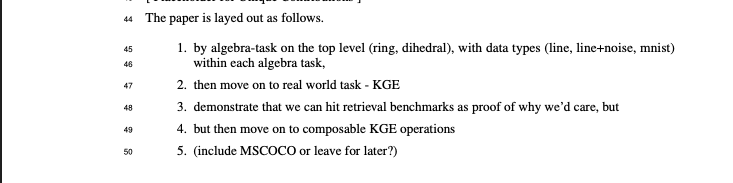

How do we get it to not do that?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

I can't see the screenshot — it's an image file type that isn't supported in my current view. But I think I know what's happening.

In LaTeX, a blank line between two `\item` commands creates a paragraph break, which inserts extra vertical space — that's probably what you're seeing as "entire blank lines" between items.

The `make_list` function itself filters out non-matching lines (including blanks), so the output it generates should be clean. The blank lines are likely coming from the calling code in the conversion pipeline — perhaps blank lines between list items in your markdown source are being passed through as regular text *before* or *after* the `itemize` environment, or the main conversion loop isn't grouping consecutive list lines together before calling `make_list`.

Could you check the generated `.tex` file and see whether there are literal blank lines between the `\item` lines inside the `itemize` environment? That would confirm whether it's a source issue or a LaTeX spacing default issue.

Yeah, the actual LaTeX looks exactly like you would see: 
```
The paper is layed out as follows.

\begin{enumerate}
\item by algebra-task on the top level (ring, dihedral), with data types (line, line+noise, mnist) within each algebra task, 
\item then move on to real world task - KGE 
\item demonstrate that we can hit retrieval benchmarks as proof of why we'd care, but 
\item but then move on to composable KGE operations
\item (include MSCOCO or leave for later?) 
\end{enumerate}
```
But when it actually gets printed out, there's unwanted blank line space between each list item. I don't want that, I don't want paragraph breaks. It serves no purpose. And especially for a scientific application where Space is a premium. I want that gone.


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That's a LaTeX default behavior — the list environments add `\itemsep` spacing between items. The fix is the `enumitem` package, which lets you control or eliminate that spacing.

Add this to your preamble:

```latex
\usepackage{enumitem}
```

Then either set it globally:

```latex
\setlist{nosep}
```

or per-environment:

```latex
\begin{enumerate}[nosep]
```

`nosep` removes all the extra inter-item spacing, paragraph spacing, and top/bottom margins — giving you the tight, compact list you want for a space-constrained paper.

If you want fine control instead of `nosep`, you can use `[itemsep=0pt, parsep=0pt, topsep=0pt]` individually. But `nosep` is the shorthand for all of those at once.

In [ ]:
def make_list(lines: list, nosep=True):
    "Convert markdown list lines to LaTeX itemize/enumerate environment."
    import re 
    env = 'itemize' # default to bulleted lists. detect if they're numbered, below
    processed = []
    for line in lines:
        m = re.match(r'^([*-]\s+|\d+\.\s+)', line)
        if m:
            if re.match(r'\d+\.', m.group(1)): env = 'enumerate'
            processed.append(r'\item ' + line[len(m.group(1)):])
    out = [fr'\begin{{{env}}}']
    if nosep: out[0] += '[nosep]'
    out.extend(processed)
    out.append(fr'\end{{{env}}}')
    return '\n'.join(out)

In [ ]:
test_str = """
1. numbered line 1 
2. numbered line 2
"""
lines = test_str.split('\n') 
table_str = make_list(lines)
print(table_str) 


\begin{enumerate}[nosep]
\item numbered line 1 
\item numbered line 2
\end{enumerate}


How's that? 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Looks great — `[nosep]` is now in the output, and the `nosep=True` default means all your existing `make_list` calls will get it automatically without any changes needed.

Just make sure `\usepackage{enumitem}` is in your LaTeX preamble, otherwise `[nosep]` will cause an error.

### Tables

In [ ]:
#| export
def parse_table(lines):
    """Parse markdown table with optional caption above or below. Returns table_dict or None.
    Note: parse table doesn't care whether the caption comes first or last, *however* logic of the main export script
    only triggers table conversion when the *first line* starts with "|".  So in Markdown, the caption needs to come last.
    """
    if isinstance(lines, str): lines = lines.split('\n')
    start = 0
    while start < len(lines) and not lines[start].strip(): start += 1
    lines = lines[start:]
    caption, label = '', None
    if not lines[0].strip().startswith('|'):
        m = re.match(r'\s*\*([^*]+)\*(?:\s*\\\{#([^}]+)\})?', lines[0])
        if m: caption, label = m.group(1), m.group(2); lines = lines[1:]
    if not lines or not lines[0].startswith('|'): return None
    i = 0
    while i < len(lines) and lines[i].startswith('|'): i += 1
    if i < 3: return None
    sep = [c.strip() for c in lines[1].split('|')[1:-1]]
    aligns = ['c' if c.startswith(':') and c.endswith(':') else 'r' if c.endswith(':') else 'l' for c in sep]
    headers = [c.strip() for c in lines[0].split('|')[1:-1]]
    rows = []
    for r in lines[2:i]:
        if r.strip().startswith('| ---'): rows.append(None)   # allow for midrules
        else: rows.append([c.strip() for c in r.split('|')[1:-1]])
    if i < len(lines):
        m = re.match(r'\s*\*([^*]+)\*(?:\s*\\\{#([^}]+)\})?', lines[i])
        if m: caption, label = m.group(1), m.group(2)
    return {'headers': headers, 'rows': rows, 'alignments': aligns, 'caption': caption, 'label': label}


In [ ]:
# test it
test_str = r"""
| lambda-neg | *TEST* MRR ↑ | H@1 ↑ | H@3 ↑ | H@10 ↑ | MR(cos) ↓ |
|---|---|---|---|---|---|
| 0 | 0.457 | 0.395 | 0.487 | 0.573 | ~1300 |
| 0.003 | 0.4645 | 0.402 | 0.497 | 0.576 | 1236 |
| 0.01 | 0.4746 | 0.414 | 0.504 | 0.585 | 1233 |
| ---
| 0.03 | 0.489 | 0.431 | 0.519 | 0.592 | **1180** |
| 0.20 (champion) | **0.5151** | **0.4665** | **0.5327** | **0.6151** | 1749 |
 *The contrastive lever — `--lambda-neg` sweep (WN18RR, order2 nd512 lambd0.10)* \{#tab:contr}
"""
table_dict = parse_table(test_str) 
table_dict

{'headers': ['lambda-neg',
  '*TEST* MRR ↑',
  'H@1 ↑',
  'H@3 ↑',
  'H@10 ↑',
  'MR(cos) ↓'],
 'rows': [['0', '0.457', '0.395', '0.487', '0.573', '~1300'],
  ['0.003', '0.4645', '0.402', '0.497', '0.576', '1236'],
  ['0.01', '0.4746', '0.414', '0.504', '0.585', '1233'],
  None,
  ['0.03', '0.489', '0.431', '0.519', '0.592', '**1180**'],
  ['0.20 (champion)',
   '**0.5151**',
   '**0.4665**',
   '**0.5327**',
   '**0.6151**',
   '1749']],
 'alignments': ['l', 'l', 'l', 'l', 'l', 'l'],
 'caption': 'The contrastive lever — `--lambda-neg` sweep (WN18RR, order2 nd512 lambd0.10)',
 'label': 'tab:contr'}

In [ ]:
#| export
def md_to_latex_bold(text: str):
    return re.sub(r'\*\*([^*]+)\*\*', r'\\textbf{\1}', text)

In [ ]:
#| export
md_to_latex_bold('| 0.20 (champion) | **0.5151** | **0.4665** | **0.5327** | **0.6151** | 1749 |')

'| 0.20 (champion) | \\textbf{0.5151} | \\textbf{0.4665} | \\textbf{0.5327} | \\textbf{0.6151} | 1749 |'

In [ ]:
test_str = r"""**Joint-Embedding Predictive Architectures.**
LeJEPA~\cite{balestriero2025lejepa} provides a theoretically grounded self-supervised objective combining an attraction loss with Sketched Isotropic Gaussian Regularization (SIGReg)."""
md_to_latex_bold(test_str)

'\\textbf{Joint-Embedding Predictive Architectures.}\nLeJEPA~\\cite{balestriero2025lejepa} provides a theoretically grounded self-supervised objective combining an attraction loss with Sketched Isotropic Gaussian Regularization (SIGReg).'

In [ ]:
#| export
def md_to_latex_italic(text: str):
    return re.sub(r'\*([^*]+)\*', r'\\textit{\1}', text)

In [ ]:
md_to_latex_italic(r"""Hey, *this emphasized* 'cause it's important""")

"Hey, \\textit{this emphasized} 'cause it's important"

In [ ]:
#| export
def make_table(tbl: dict):
    "Generate LaTeX table environment from parsed table dict."
    col_spec = ''.join(tbl['alignments'])
    lines = [r'\begin{table}[htbp]', r'\centering']
    if tbl.get('caption'): lines.append(r'\caption{' + tbl['caption'] + '}')
    if tbl.get('label'): lines.append(r'\label{tab:' + tbl['label'] + '}')
    lines.append(r'\begin{tabular}{' + col_spec + '}')
    lines.append(r'\toprule')
    lines.append(' & '.join(tbl['headers']) + r' \\')
    lines.append(r'\midrule')
    for row in tbl['rows']:
        if row is None: lines.append(r'\midrule')
        else: lines.append(' & '.join(md_to_latex_bold(cell) for cell in row) + r' \\')
    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')
    return md_to_latex_italic('\n'.join(lines))


In [ ]:
table_tex = make_table(table_dict)
print(table_tex)

\begin{table}[htbp]
\centering
\caption{The contrastive lever — `--lambda-neg` sweep (WN18RR, order2 nd512 lambd0.10)}
\label{tab:tab:contr}
\begin{tabular}{llllll}
\toprule
lambda-neg & \textit{TEST} MRR ↑ & H@1 ↑ & H@3 ↑ & H@10 ↑ & MR(cos) ↓ \\
\midrule
0 & 0.457 & 0.395 & 0.487 & 0.573 & ~1300 \\
0.003 & 0.4645 & 0.402 & 0.497 & 0.576 & 1236 \\
0.01 & 0.4746 & 0.414 & 0.504 & 0.585 & 1233 \\
\midrule
0.03 & 0.489 & 0.431 & 0.519 & 0.592 & \textbf{1180} \\
0.20 (champion) & \textbf{0.5151} & \textbf{0.4665} & \textbf{0.5327} & \textbf{0.6151} & 1749 \\
\bottomrule
\end{tabular}
\end{table}


In [ ]:
# try this...
table_in_md = r"""
| Level | Patch size | grid | depth | heads | dim |
|:--:|:--:|:--:|:--:|:--:|:--:|
| 5 | $4\times4$px | $32\times32$ | 2 | 2 | 8 |
| 4 | $8\times8$ | $16\times16$ | 2 | 2 | 16 |
| 3 | $16\times16$ | $8\times8$ | 2 | 2 | 32 |
| 2 | $32\times32$ | $4\times4$ | 6 | 4 | 64 |
| 1 | $64\times64$ | $2\times2$ | 2 | 8 | 128 |
| 0 | $128\times128$ | $1\times1$ | 1 | 16 | 256 |
*Architecture configuration. Visualized in Figure~\ref{fig:arch}.* \{#arch}
"""
table_dict = parse_table(table_in_md) 
table_out = make_table(table_dict) 
print(table_out)

\begin{table}[htbp]
\centering
\caption{Architecture configuration. Visualized in Figure~\ref{fig:arch}.}
\label{tab:arch}
\begin{tabular}{cccccc}
\toprule
Level & Patch size & grid & depth & heads & dim \\
\midrule
5 & $4\times4$px & $32\times32$ & 2 & 2 & 8 \\
4 & $8\times8$ & $16\times16$ & 2 & 2 & 16 \\
3 & $16\times16$ & $8\times8$ & 2 & 2 & 32 \\
2 & $32\times32$ & $4\times4$ & 6 & 4 & 64 \\
1 & $64\times64$ & $2\times2$ & 2 & 8 & 128 \\
0 & $128\times128$ & $1\times1$ & 1 & 16 & 256 \\
\bottomrule
\end{tabular}
\end{table}


In [ ]:
#| export
def export_ordered(curr_path, output_path=None):
    """Uses user-defined syntax '#| replaces: <msg_id>' to replace earlier messages with later ones 
    msg_id be obtained in the GUI by pressing the link button.
    Valid syntax usages (with or without colons): 
        #| replaces: https://serene-vision-dives-ildq3w.solve.it.com/dialog_?name=solveit-tex/solveit-tex#_a0d44aac
        #| replaces _a0d44aac
    """
    if output_path is None: output_path = curr_path.replace('.ipynb', '-out.ipynb')
    nb = json.loads(Path(curr_path).read_text())
    
    # Pass 1: find replacements {target_id -> cell}, last-wins
    replacements = {}
    for cell in nb['cells']:
        content = ''.join(cell['source'])
        if not content.lstrip().startswith('#| export'): continue
        for line in content.split('\n'):
            if line.startswith('#| replaces:'):
                target = line.split('#')[-1].strip('_')
                replacements[target] = cell
    
    # Pass 2: walk in order, apply replacements, keep only exported
    out_cells = []
    for cell in nb['cells']:
        content = ''.join(cell['source'])
        if not content.lstrip().startswith('#| export'): continue
        cid = cell.get('id', '').strip('_')
        if cid in replacements:
            rcell = replacements[cid]
            rcontent = '\n'.join(l for l in ''.join(rcell['source']).split('\n') if not l.startswith('#| replaces'))
            lines = rcontent.split('\n')
            rcontent = [l + '\n' for l in lines[:-1]] + [lines[-1]]
            out_cells.append({**rcell, 'source': rcontent})
        else:
            if any(l.startswith('#| replaces') for l in content.split('\n')): continue  # don't re-add replacements
            out_cells.append(cell)
    
    nb['cells'] = out_cells
    Path(output_path).write_text(json.dumps(nb, indent=1))
    print(f'Exported {len(out_cells)} cells to {output_path}')
    return output_path 

## Export Preserving Ordering via '#| replaces \<msgid\>' 

In [ ]:
export_ordered(curr_dialog_path)

Exported 14 cells to /app/data/solveit-tex/solveit-tex-out.ipynb


'/app/data/solveit-tex/solveit-tex-out.ipynb'

## Conversion script for .ipynb -> .tex

In [ ]:
#| export
def export_ipynb_to_tex(ipynb_path: str, output_path: str = None, ordered=True):
    r"""Export a Solveit dialog (.ipynb) to a compilable LaTeX file.
    Cells are emitted in document order, each preceded by a `% <cell-id>` comment.
    The `## Abstract` cell emits `\begin{document}`, dividing preamble from document body."""

    ipynb_path = os.path.expanduser(ipynb_path)

    if ordered:  # Export preserving "#| replaces" ordering. Writes to -out.ipynb first. That becomes the input file 
        ipynb_path = export_ordered(ipynb_path)
        
    output_path = os.path.expanduser(output_path) if output_path else Path(ipynb_path).with_suffix('.tex')
    if ordered: output_path = str(output_path).replace('-out.tex', '.tex')
    print("output_path =",output_path)

    nb = json.loads(Path(ipynb_path).read_text())
    out = []
    title = 'TITLE NOT FOUND'
    for cell in nb['cells']:
        content = ''.join(cell['source'])
        content = md_to_latex_bold(content)
        if '#| export' not in content: continue

        filtered = '\n'.join(l for l in content.split('\n') if not l.startswith('#| '))
        out.append(f'% {cell["id"]}')

        if cell['cell_type'] == 'raw':
            out.append(filtered)
            continue

        lines = filtered.split('\n')
        i = 0
        while i < len(lines):
            line = lines[i]
            if line.startswith('# ') and not line.startswith('## '):
                title = f'{line[2:].strip()}'
            elif line.startswith('\\author{'):
                out.append(line)
                while i < len(lines) and not lines[i].strip().endswith('}'):
                    i += 1
                    if i < len(lines): out.append(lines[i])
            elif line == '## Abstract':
                out.append(f'\\title{{{title}}}\n')
                out.append('\\begin{document}\n\n\\maketitle\n')
                out.append('\\begin{abstract}\n')
                i += 1
                while i < len(lines) and not lines[i].startswith('## '):
                    out.append(lines[i])
                    i += 1
                out.append('\\end{abstract}\n')
                continue
            elif line == '## References':
                out.append('\\small\n')
                i += 1
                while i < len(lines) and not lines[i].startswith('## '):
                    l = lines[i]
                    if l.strip().startswith('\\bibliographystyle'):
                        out.append(l + '\n')
                    bib_match = re.search(r'(\w+)\.bib', l)
                    if bib_match:
                        out.append(f'\\bibliography{{{bib_match.group(1)}}}\n')
                    i += 1
                continue
            elif line.startswith('### '):
                out.append(f'\\subsection{{{line[4:].strip()}}}\n')
            elif line.startswith('## '):
                out.append(f'\\section{{{line[3:].strip()}}}\n')
            elif re.match(r'^[*-]\s+|^\d+\.\s+', line):  # list handling (no nested list support yet!)
                list_lines = [line]
                i += 1
                while i < len(lines) and re.match(r'^[*-]\s+|^\d+\.\s+', lines[i]):
                    list_lines.append(lines[i])
                    i += 1
                out.append(make_list(list_lines))
                continue
            elif line.startswith('|'):    # table handling
                # Collect table lines
                table_lines = []
                while i < len(lines) and lines[i].startswith('|'):
                    table_lines.append(lines[i])
                    i += 1
                # Check for caption line
                if i < len(lines) and re.match(r'\s*\*', lines[i]):
                    table_lines.append(lines[i])
                    i += 1
                # Parse and convert
                tbl_dict = parse_table(table_lines)
                if tbl_dict:
                    out.append(make_table(tbl_dict))
                continue  # Skip the i += 1 at the end    
            else:         # figures
                fig_dict = parse_figure(line)
                if fig_dict:
                    out.append(make_figure(fig_dict))
                else:
                    out.append(line)

            i += 1

    final = '\\documentclass{article}\n'
    # packages we definitely want. Hopefully these will be compatible with style files, etc.
    final += '\\usepackage{graphicx}\n\\usepackage{booktabs}\n\\usepackage{enumitem}\n'
    final += '\n'.join(out) + '\n\n'
    final += '\\end{document}\n'
    final = md_to_latex_italic(final)
    
    Path(output_path).write_text(final)
    print(f'Created {output_path}')
    output_url = get_private_url(output_path)
    display(HTML(f'<a href="{output_url}" target="_blank">{output_url}</a>'))

In [ ]:
export_ipynb_to_tex('example/neurips_2026.ipynb')

Exported 22 cells to example/neurips_2026-out.ipynb


output_path = example/neurips_2026.tex


Created example/neurips_2026.tex


HTML(<a href="https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.tex" target="_blank">https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.tex</a>)

In [ ]:
export_ipynb_to_tex('~/hoplas-paper/hoplas-paper.ipynb')

Exported 13 cells to /app/data/hoplas-paper/hoplas-paper-out.ipynb


output_path = /app/data/hoplas-paper/hoplas-paper.tex


Created /app/data/hoplas-paper/hoplas-paper.tex


HTML(<a href="https://serene-vision-dives-ildq3w.solve.it.com/static/hoplas-paper/hoplas-paper.tex" target="_blank">https://serene-vision-dives-ildq3w.solve.it.com/static/hoplas-paper/hoplas-paper.tex</a>)

I think I just noticed an issue: does `md_to_latex_bold` only run for tables?  In theory, any markdown-bold text anywhere in the latex document should get converted appropriately.   So how do we fix that

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good catch! Right now `md_to_latex_bold` is only called inside `make_table`, so `**bold**` text in regular paragraphs, figure captions, section titles, etc. passes through unconverted.

The simplest fix: apply `md_to_latex_bold` in the `else` branch of `export_ipynb_to_tex` where regular content lines are emitted. That's the catch-all for non-special lines. Something like:

```python
else:
    fig_dict = parse_figure(line)
    if fig_dict:
        out.append(make_figure(fig_dict))
    else:
        out.append(md_to_latex_bold(line))
```

You might also want it applied to figure captions (inside `make_figure`) and section/subsection titles, depending on whether you use bold in those contexts. Want to start with just the regular content lines, or cover all those spots too?

Yeah, I really think it should just be applied globally, even apart from any kind of logical switches. Like, just apply it to the whole document early on.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That makes sense — simplest approach is to apply it to `final` right before writing it out:

```python
final = md_to_latex_bold(final)
```

That single line, just before `Path(output_path).write_text(final)`, would catch every `**bold**` occurrence across the whole document regardless of where it appears. You could then also remove the per-cell call in `make_table` since it'd be redundant.

One thing to watch for: if any LaTeX already contains literal `**` for a non-bold reason (unlikely but possible), it'd get caught too. But that's probably not a concern for your use case.

Wait, why are you doing it at the very end instead of at the very beginning?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're right — applying it at the beginning is better. Do it right after reading each cell's content, before any of the parsing logic runs. That way tables, figures, sections, and regular text all get converted in one pass, and you don't need any special-case calls downstream.

In `export_ipynb_to_tex`, right after:

```python
content = ''.join(cell['source'])
```

add:

```python
content = md_to_latex_bold(content)
```

Then you can remove the `md_to_latex_bold` call inside `make_table` since it's already been applied. Want to make that change?

## Conversion script for tex -> pdf

In [ ]:
#| export
def compile_latex(tex_file: str, cwd: str = '.'):
    "Run full LaTeX compilation: pdflatex → bibtex → pdflatex → pdflatex"

    cwd = os.path.expanduser(cwd)
    tex_file = os.path.expanduser(tex_file)
    
    # Make path absolute before splitting
    full_tex_path = os.path.abspath(os.path.join(cwd, tex_file))
    work_dir = os.path.dirname(full_tex_path)
    
    base_name = os.path.splitext(os.path.basename(full_tex_path))[0]
    tex_content = Path(full_tex_path).read_text()
    bib_match = re.search(r'\\bibliography\{([^}]+)\}', tex_content)
    
    print("Running pdflatex (pass 1)...")
    r1 = subprocess.run(f'pdflatex -halt-on-error {full_tex_path}',
                   shell=True, cwd=work_dir, capture_output=True, text=True)
    if r1.returncode != 0:
        print(f"  FAILED:\n{r1.stdout[-3000:]}")
        return
    
    if bib_match:
        bib_name = bib_match.group(1)
        print(f"\nRunning bibtex ({bib_name})...")
        r = subprocess.run(f'bibtex {base_name}',
                          shell=True, cwd=work_dir, capture_output=True, text=True)
        if r.returncode != 0:
            print(f"  FAILED:\n{r.stdout}")
            return
    
    for i in [2, 3]:
        print(f"\nRunning pdflatex (pass {i})...")
        r = subprocess.run(f'pdflatex -halt-on-error {full_tex_path}',
                       shell=True, cwd=work_dir, capture_output=True, text=True)
        if r.returncode != 0:
            print(f"  FAILED:\n{r.stdout[-3000:]}")
            return

    pdf_path = full_tex_path.replace('.tex', '.pdf') 
    pdf_url = get_private_url(pdf_path)
    print(f"\nSuccess!")
    print(f"File: {pdf_path}")
    print(f"PDF url: {pdf_url}")
    sys.stdout.flush() 
    display(HTML(f'<a href="{pdf_url}" target="_blank">{pdf_url}</a>'))

In [ ]:
compile_latex('example/neurips_2026.tex')

Running pdflatex (pass 1)...



Running bibtex (references)...



Running pdflatex (pass 2)...



Running pdflatex (pass 3)...



Success!


File: /app/data/solveit-tex/example/neurips_2026.pdf


PDF url: https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.pdf


HTML(<a href="https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.pdf" target="_blank">https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.pdf</a>)

In [ ]:
compile_latex('~/hoplas-paper/hoplas-paper.tex')

Running pdflatex (pass 1)...



Running bibtex (references)...


  FAILED:
This is BibTeX, Version 0.99e (TeX Live 2026)
The top-level auxiliary file: hoplas-paper.aux
I found no \bibstyle command---while reading file hoplas-paper.aux
(There was 1 error message)


## All-in-One Wrapper Function

In [ ]:
#| export
async def current_to_pdf():
    """
    Wrapper that converts the current dialogue to PDF and prints the private URL for it.
    Usage: await current_to_pdf()
    """
    curr_dialog_path = await get_curr_dialog_path()
    export_ipynb_to_tex(curr_dialog_path)
    display(HTML(f'<br>'))
    compile_latex(curr_dialog_path.replace('.ipynb', '.tex'))

## Submission Package (for ArXiv) 

In [ ]:
#| export
def create_submission_package(project_dir:str='.'): 
    "Make a .tar.gz archive suitable for submission to arxiv, etc"
    import shutil, tarfile
    from rgapi.skill import fd
    
    extensions = ['tex','png','jpg','tikz','eps','sty','bib','bst']
    project_path = Path(project_dir).expanduser().resolve()
    project_name = project_path.name
    tmp_dir = Path(f'/tmp/{project_name}')
    if tmp_dir.exists(): shutil.rmtree(tmp_dir)
    tmp_dir.mkdir(parents=True)
    files = [Path(project_path) / f for f in fd(project_path, ext=extensions)]
    print("Files included:\n",[str(f) for f in files])
    for f in files:  
        dest = tmp_dir / f.relative_to(project_path)
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(f, dest)
    pkg_path = Path(project_path) / f'{project_name}.tar.gz'
    with tarfile.open(pkg_path, 'w:gz') as tar:
        tar.add(tmp_dir, arcname=project_name)
    pkg_url = get_private_url(str(pkg_path))
    display(HTML(f'<a href="{pkg_url}" target="_blank">{pkg_url}</a>'))
    return str(pkg_path)

In [ ]:
create_submission_package('example')

Files included:


 ['/app/data/solveit-tex/example/neurips_2026.sty', '/app/data/solveit-tex/example/references.bib']


HTML(<a href="https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/example.tar.gz" target="_blank">https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/example.tar.gz</a>)

'/app/data/solveit-tex/example/example.tar.gz'

## Allow LLM to call routines herein

In [ ]:
#| export
from pyskills import allow 

allow(export_ipynb_to_tex)
allow(current_to_pdf)
allow(compile_latex) 
allow(create_submission_package)

<function __main__.create_submission_package(project_dir: str = '.')>